## **RESPON MODUL 5**

In [84]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import pandas as pd

Kode diatas berfungsi untuk mengimpor beberapa pustaka utama. NumPy digunakan untuk komputasi numerik dan operasi matriks, sementara Matplotlib bertugas menampilkan grafik serta visualisasi gambar. Untuk pemrosesan citra digital, kode ini mengandalkan OpenCV, yang kemudian dikombinasikan dengan Pandas untuk mengelola dan menganalisis data terstruktur secara efisien.

Kode dibawah digunakan untuk membaca dan menampilkan sebuah gambar dalam format keabuan (grayscale). Pertama, gambar bernama 'doomsday.jpg' dibaca menggunakan OpenCV. Karena secara default OpenCV membaca gambar dalam format warna BGR, kode selanjutnya mengubah gambar tersebut menjadi format grayscale (hitam-putih). Terakhir, gambar yang sudah diubah ditampilkan menggunakan Matplotlib dengan skema warna abu-abu (cmap='gray') dan diberi judul 'Doomsday'.

Text(0.5, 1.0, 'Doomsday')

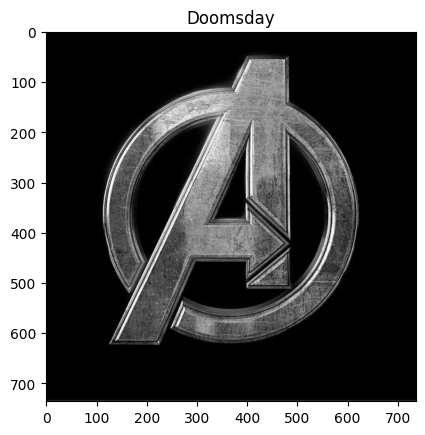

In [85]:
img_doomsday = cv.imread('doomsday.jpg')
img_doomsday_gray = cv.cvtColor(img_doomsday, cv.COLOR_BGR2GRAY)
plt.imshow(img_doomsday_gray, cmap='gray')
plt.title('Doomsday')

In [86]:
nilai = 1 / 1.4142135623730950488016887242097
LPF = np.array([1/np.sqrt(2), 1/np.sqrt(2)])
HPF = np.array([1/np.sqrt(2), -(1/np.sqrt(2))])

def convo_h(image, kernel):
    ukuran_kernel = len(kernel)
    padd = np.pad(image, ((0, 0), (ukuran_kernel // 2, ukuran_kernel // 2)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    
    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += (padd[i][j + x] * kernel[x])
    return conv

def convo_v(image, kernel):
    ukuran_kernel = len(kernel)
    padd = np.pad(image, ((ukuran_kernel // 2, ukuran_kernel // 2), (0, 0)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    
    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += (padd[i + x][j] * kernel[x])
    return conv

def downsampling_h(image):
    tinggi, lebar = image.shape[0], image.shape[1]
    downsampled = np.zeros((tinggi, lebar // 2))
    
    for i in range(len(downsampled)):
        indeks = 0  
        for j in range(len(downsampled[i])):
            downsampled[i][j] = image[i][indeks]
            indeks += 2
    return downsampled

def downsampling_v(image):
    baris = int(image.shape[0] / 2)
    kolom = int(image.shape[1])
    downsampled = np.zeros((baris, kolom))
    
    indeks = 0
    for i in range(baris):
        for j in range(kolom):
            downsampled[i][j] = image[indeks][j]
        indeks += 2 
    return downsampled

def normalisasi(image):
    return (image - np.min(image)) / (np.max(image) - np.min(image)) * 255

Kode diatas mengimplementasikan tahap dasar dari transformasi wavelet diskrit (Discrete Wavelet Transform/DWT) pada citra secara manual menggunakan filter Haar. Di awal, kode mendefinisikan filter LPF (Low Pass Filter) untuk mengambil informasi halus atau rata-rata gambar, dan HPF (High Pass Filter) untuk mengambil informasi detail atau tepi gambar, memanfaatkan nilai konstanta $1/\sqrt{2}$.

Selanjutnya, terdapat dua fungsi konvolusi 1D, yaitu convo_h untuk menyaring gambar secara horizontal dan convo_v secara vertikal dengan menambahkan padding nol agar ukuran gambar tetap terjaga selama proses perkalian matriks. Setelah proses penyaringan, fungsi downsampling_h dan downsampling_v digunakan untuk mereduksi ukuran gambar menjadi setengahnya dengan cara mengambil piksel pada indeks genap saja (skipping berjarak 2), masing-masing untuk arah horizontal dan vertikal. Di akhir, fungsi normalisasi memetakan kembali nilai intensitas piksel gambar hasil pemrosesan ke rentang standar 0 hingga 255 agar gambar dapat divisualisasikan dengan benar.

In [87]:
def wavelet(image):
    konvolusi1 = convo_h(image, LPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, LPF)
    approximation = downsampling_v(konvolusi2)
    approximation = normalisasi(approximation)
    
    konvolusi1 = convo_h(image, LPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, HPF)
    horizontal = downsampling_v(konvolusi2)
    horizontal = normalisasi(horizontal)
    
    konvolusi1 = convo_h(image, HPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, LPF)
    vertikal = downsampling_v(konvolusi2)
    vertikal = normalisasi(vertikal)
    
    konvolusi1 = convo_h(image, HPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, HPF)
    diagonal = downsampling_v(konvolusi2)
    diagonal = normalisasi(diagonal)
    
    return (approximation, horizontal, vertikal, diagonal)

Fungsi wavelet diatas merupakan implementasi utama untuk melakukan dekomposisi Transformasi Wavelet Diskrit (DWT) tingkat pertama. Fungsi ini bekerja dengan membagi citra asli ke dalam empat komponen sub-band frekuensi yang berbeda melalui kombinasi penyaringan menggunakan filter LPF dan HPF serta pengurangan ukuran (downsampling) baik secara horizontal maupun vertikal. Keempat komponen yang dihasilkan meliputi sub-band approximation (LL) yang berisi ringkasan informasi halus atau versi resolusi rendah dari citra asli, sub-band horizontal (LH) yang mendeteksi detail garis horizontal, sub-band vertikal (HL) yang menonjolkan fitur garis vertikal, serta sub-band diagonal (HH) yang menangkap detail tepi arah diagonal. Sebelum fungsi ini mengembalikan hasil akhir berupa keempat sub-band tersebut secara bersamaan, setiap matriks komponen terlebih dahulu diproses melalui fungsi normalisasi agar nilai intensitas pikselnya berada dalam rentang yang tepat dan siap untuk divisualisasikan.

Kode dibawah berfungsi untuk mengeksekusi fungsi dekomposisi wavelet pada gambar 'img_doomsday_gray' dan menampilkan hasilnya ke dalam satu area plot. Pertama, fungsi wavelet dipanggil untuk memecah citra grayscale tersebut menjadi empat komponen sub-band, yaitu LL (Approximation), LH (Horizontal), HL (Vertikal), dan HH (Diagonal). Selanjutnya, sebuah jendela gambar (figure) disiapkan dengan ukuran 10x10 inci menggunakan Matplotlib. Dengan menggunakan fungsi subplot, area plot dibagi menjadi kisi berukuran 2x2 sehingga keempat matriks sub-band dapat ditampilkan secara bersamaan dalam bentuk gambar hitam-putih (cmap='gray') lengkap dengan judulnya masing-masing. Di akhir kode, perintah tight_layout digunakan untuk merapikan tata letak agar teks atau grafik tidak saling tumpang tindih sebelum gambar keseluruhan ditampilkan ke layar.

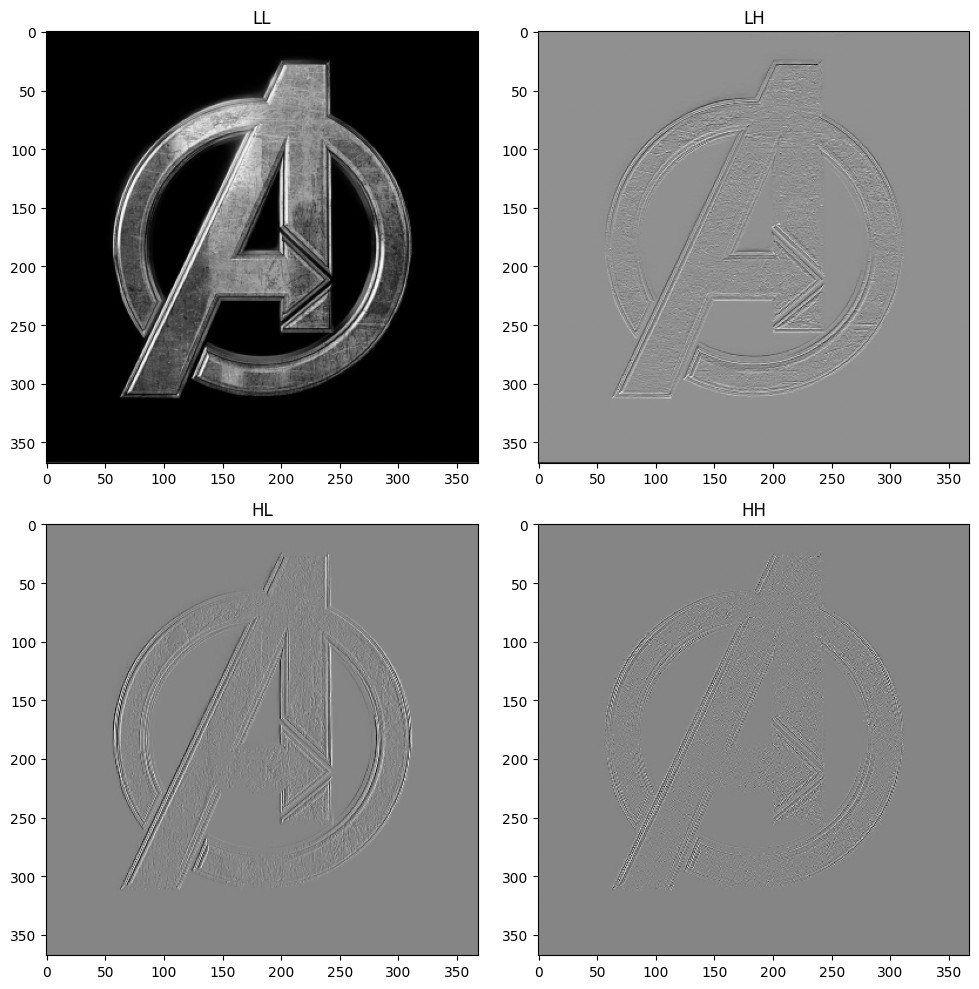

In [88]:
LL, LH, HL, HH = wavelet(img_doomsday_gray)

plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.imshow(LL, cmap='gray')
plt.title("LL")

plt.subplot(2, 2, 2)
plt.imshow(LH, cmap='gray')
plt.title("LH")

plt.subplot(2, 2, 3)
plt.imshow(HL, cmap='gray')
plt.title("HL")

plt.subplot(2, 2, 4)
plt.imshow(HH, cmap='gray')
plt.title("HH")

plt.tight_layout()
plt.show()

In [89]:
def threshold_manual(img, nilai_threshold):
    h, w = img.shape
    hasil = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            if img[i,j] > nilai_threshold:
                hasil[i,j] = 255
            else:
                hasil[i,j] = 0
    return hasil

Fungsi threshold_manual diatas digunakan untuk melakukan proses pengambangan (thresholding) secara manual pada sebuah citra guna mengubahnya menjadi citra biner (hitam-putih). Di awal fungsi, dimensi tinggi dan lebar dari citra masukan diambil, kemudian sebuah matriks baru bernama hasil disiapkan dengan ukuran yang sama dan diinisialisasi dengan nilai nol (warna hitam). Selanjutnya, fungsi ini menggunakan perulangan bersarang (nested loop) untuk memeriksa nilai intensitas setiap piksel pada citra asli satu per satu. Jika nilai intensitas piksel pada posisi tersebut lebih besar dari nilai_threshold yang ditentukan, maka piksel pada matriks hasil akan diubah menjadi 255 (warna putih). Sebaliknya, jika nilainya kurang dari atau sama dengan nilai ambang batas tersebut, piksel akan tetap bernilai 0 (warna hitam). Setelah semua piksel selesai diperiksa, fungsi ini mengembalikan citra biner hasil segmentasi tersebut.

Kode dibawah berfungsi untuk menerapkan segmentasi biner (thresholding) secara manual pada sub-band detail hasil transformasi wavelet dan menampilkan perbandingannya dalam satu baris plot. Pertama, fungsi threshold_manual dipanggil sebanyak tiga kali untuk memproses sub-band HL (Vertikal), LH (Horizontal), dan HH (Diagonal) secara bergantian menggunakan nilai ambang batas (threshold) sebesar 150. Proses ini akan mengubah piksel-piksel pada ketiga komponen detail tersebut menjadi murni hitam dan putih berdasarkan nilai batas yang ditentukan. Setelah itu, sebuah jendela grafik berukuran 10x10 inci disiapkan menggunakan Matplotlib dengan tata letak kisi 1x3 (subplot satu baris dan tiga kolom). Ketiga citra biner hasil pengambangan tersebut kemudian ditampilkan berdampingan menggunakan skema warna abu-abu (cmap='gray'), lengkap dengan judul indeksnya masing-masing seperti "HL Thresholding", "LH Thresholding", dan "HH Thresholding", lalu dirapikan dengan tight_layout sebelum akhirnya ditampilkan ke layar.

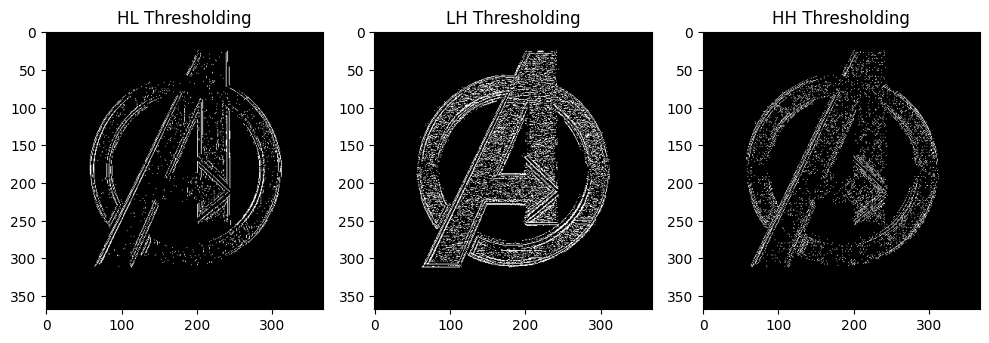

In [90]:
img_threshold = threshold_manual(HL, 150)
img_threshold2 = threshold_manual(LH, 150)
img_threshold3 = threshold_manual(HH, 150)

plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.imshow(img_threshold, cmap='gray')
plt.title("HL Thresholding")

plt.subplot(1, 3, 2)
plt.imshow(img_threshold2, cmap='gray')
plt.title("LH Thresholding")

plt.subplot(1, 3, 3)
plt.imshow(img_threshold3, cmap='gray')
plt.title("HH Thresholding")
plt.tight_layout()
plt.show()

In [91]:
def metode_satu(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255
            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0
    return hasil

def metode_dua(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

Kode diatas mengimplementasikan dua fungsi manual, yaitu dilasi (dilation) dan erosi (erosion) menggunakan elemen struktur (kernel). Fungsi pertama, metode_satu, merupakan fungsi dilasi yang bekerja dengan cara memperluas atau mempertebal objek berwarna putih (nilai 255) pada citra, dimana jika piksel pusat pada citra asli bernilai 255, maka seluruh area di sekitarnya yang tertutup oleh bentuk kernel berorientasi nilai 1 akan ikut diubah menjadi putih pada matriks hasil. Sementara itu, fungsi kedua, metode_dua, merupakan fungsi erosi yang bekerja dengan cara mengikis atau mempertipis tepi objek putih, fungsi ini menggunakan logika pencocokan penuh (fit), di mana piksel pusat pada matriks hasil hanya akan diubah menjadi putih jika seluruh bagian kernel bernilai 1 tepat bertumpu pada piksel citra asli yang juga bernilai 255. Kedua fungsi ini memanfaatkan perulangan bersarang untuk memindai setiap piksel citra dan mengabaikan area tepi luar yang tidak terjangkau oleh ukuran kernel (border handling).

Kode dibawah menerapkan operasi morfologi Closing yang sebenarnya pada tiga sub-band hasil thresholding (HL, LH, dan HH) menggunakan kernel berbentuk belah ketupat berukuran 5x5 (kernel5), lalu menampilkan perbandingannya dalam satu baris plot. Proses closing dilakukan secara manual dengan melewatkan setiap sub-band ke fungsi dilasi (metode_satu) terlebih dahulu untuk mengisi kekosongan, kemudian hasilnya langsung diteruskan ke fungsi erosi (metode_dua) guna mengembalikan ketebalan objek ke ukuran semula.

Berdasarkan analisis karakteristik hasilnya, operasi closing yang sesungguhnya ini memberikan struktur gambar yang jauh lebih bersih, rapi, dan proporsional dibandingkan hanya melakukan dilasi tunggal. Operasi ini berhasil menutup lubang-lubang kecil (lubang hitam berbentuk belah ketupat/diamond) di dalam objek dan menyambungkan kembali garis-garis logo Avengers yang sempat terputus tanpa membuat ukuran garisnya menjadi bengkak atau melebar. Pada LH Closing, logo terlihat paling utuh dan solid karena komponen horizontal mendominasi bentuk asli logo, dan pada HL Closing, detail dan batas tepi vertikal berhasil dipertahankan dengan tegas, sedangkan pada HH Closing, noise di area diagonal berhasil diredam dengan baik meskipun strukturnya terlihat lebih terfragmentasi karena karakteristik frekuensi tinggi pada arah diagonal.

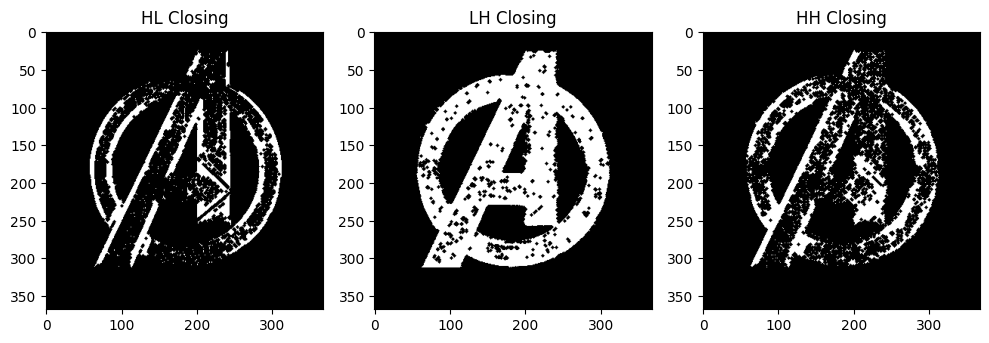

In [ ]:
kernel5 = np.array([[0, 0, 1, 0, 0],
                    [0, 1, 1, 1, 0],
                    [1, 1, 1, 1, 1],
                    [0, 1, 1, 1, 0],
                    [0, 0, 1, 0, 0]])

hl_dilated = metode_satu(img_threshold, kernel5)
img_doomsday_closing = metode_dua(hl_dilated, kernel5)

lh_dilated = metode_satu(img_threshold2, kernel5)
img_doomsday_closing2 = metode_dua(lh_dilated, kernel5)

hh_dilated = metode_satu(img_threshold3, kernel5)
img_doomsday_closing3 = metode_dua(hh_dilated, kernel5)

plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.imshow(img_doomsday_closing, cmap='gray')
plt.title("HL Closing")

plt.subplot(1, 3, 2)
plt.imshow(img_doomsday_closing2, cmap='gray')
plt.title("LH Closing")

plt.subplot(1, 3, 3)
plt.imshow(img_doomsday_closing3, cmap='gray')
plt.title("HH Closing")
plt.tight_layout()
plt.show()

In [93]:
def upsampling_v(image):
    tinggi, lebar = image.shape[0], image.shape[1]
    upsampled = np.zeros((tinggi * 2, lebar))
    
    for i in range(tinggi):
        for j in range(lebar):
            upsampled[i * 2][j] = image[i][j]
            
    return upsampled

def upsampling_h(image):
    tinggi, lebar = image.shape[0], image.shape[1]
    upsampled = np.zeros((tinggi, lebar * 2))
    
    for i in range(tinggi):
        for j in range(lebar):
            upsampled[i][j * 2] = image[i][j]
            
    return upsampled

Kode diatas mengimplementasikan dua fungsi untuk melakukan operasi peningkatan ukuran citra (upsampling) secara manual, yang merupakan langkah awal dalam proses rekonstruksi atau inversi Transformasi Wavelet Diskrit (Inverse Discrete Wavelet Transform/IDWT). Fungsi pertama, upsampling_v, digunakan untuk menduplikasi ukuran citra ke arah vertikal (memperbesar tinggi citra menjadi dua kali lipat) dengan cara menyalin setiap piksel asli ke indeks baris genap (i * 2) pada matriks baru, sementara baris ganjil di antaranya dibiarkan bernilai nol. Fungsi kedua, upsampling_h, bekerja dengan logika yang sama tetapi diterapkan ke arah horizontal (memperbesar lebar citra menjadi dua kali lipat), di mana piksel asli ditempatkan pada indeks kolom genap (j * 2) dan kolom ganjil di antaranya diisi dengan nilai nol. Kedua fungsi ini memanfaatkan perulangan bersarang (nested loop) untuk memetakan kembali posisi piksel citra beresolusi rendah ke dalam matriks beresolusi lebih tinggi sebelum mengembalikan hasil akhirnya.

In [94]:
def rekonstruksi(LL, LH, HL, HH):
    upsampling = upsampling_v(LL)
    konvolusiL = convo_v(upsampling, LPF)
    
    upsampling = upsampling_v(LH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling_gabungan1 = upsampling_h(konvolusiL + konvolusiH)
    konvolusiL2 = convo_h(upsampling_gabungan1, LPF)

    upsampling = upsampling_v(HL)
    konvolusiL = convo_v(upsampling, LPF)
    
    upsampling = upsampling_v(HH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling_gabungan2 = upsampling_h(konvolusiL + konvolusiH)
    konvolusiH2 = convo_h(upsampling_gabungan2, HPF)
    
    hasil = konvolusiL2 + konvolusiH2
    return hasil

rekonstruksi_img = rekonstruksi(LL, LH, HL, HH)
rekonstruksi_img = normalisasi(rekonstruksi_img)

Fungsi rekonstruksi diatas mengimplementasikan proses Inverse Discrete Wavelet Transform (IDWT) secara manual untuk menyatukan kembali empat sub-band frekuensi (LL, LH, HL, dan HH) menjadi satu citra utuh seperti semula. Proses rekonstruksi ini bekerja dengan urutan terbalik dari tahap dekomposisi, di mana setiap sub-band terlebih dahulu dinaikkan ukurannya secara vertikal (upsampling_v) lalu disaring menggunakan filter yang sesuai (convo_v dengan LPF atau HPF). Hasil penyaringan vertikal tersebut kemudian dikombinasikan dan dinaikkan ukurannya secara horizontal (upsampling_h) sebelum disaring kembali ke arah horizontal menggunakan filter LPF dan HPF. Pada tahap akhir, seluruh komponen frekuensi rendah dan frekuensi tinggi yang telah diproses digabungkan kembali melalui operasi penjumlahan matriks untuk membentuk citra rekonstruksi utuh, yang kemudian dilewatkan ke fungsi normalisasi agar rentang nilai pikselnya kembali standar dan siap untuk divisualisasikan dengan benar.

In [95]:
def wavelet2(image):
    konvolusi1 = convo_h(image, LPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, LPF)
    approximation = downsampling_v(konvolusi2)
    
    konvolusi1 = convo_h(image, LPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, HPF)
    horizontal = downsampling_v(konvolusi2)
    
    konvolusi1 = convo_h(image, HPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, LPF)
    vertikal = downsampling_v(konvolusi2)
    
    konvolusi1 = convo_h(image, HPF)
    downsampling = downsampling_h(konvolusi1)
    konvolusi2 = convo_v(downsampling, HPF)
    diagonal = downsampling_v(konvolusi2)
    
    return (approximation, horizontal, vertikal, diagonal)

LL, LH, HL, HH = wavelet2(img_doomsday_gray)

def rekonstruksi2(LL_sub, LH_sub, HL_sub, HH_sub):
    upsampling = upsampling_v(LL_sub)
    konvolusiL = convo_v(upsampling, LPF)
    
    upsampling = upsampling_v(LH_sub)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling_gabungan1 = upsampling_h(konvolusiL + konvolusiH)
    konvolusiL2 = convo_h(upsampling_gabungan1, LPF)

    upsampling = upsampling_v(HL_sub)
    konvolusiL = convo_v(upsampling, LPF)
    
    upsampling = upsampling_v(HH_sub)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling_gabungan2 = upsampling_h(konvolusiL + konvolusiH)
    konvolusiH2 = convo_h(upsampling_gabungan2, HPF)
    
    hasil = konvolusiL2 + konvolusiH2
 
    return normalisasi(hasil)


Blok kode diatas mendefinisikan ulang fungsi dekomposisi wavelet2 dan fungsi rekonstruksi rekonstruksi2 dengan sedikit modifikasi alur, serta langsung mengeksekusi tahap penguraian citra. Berbeda dengan fungsi versi pertama sebelumnya yang melakukan normalisasi di setiap sub-band individu (LL, LH, HL, HH), fungsi wavelet2 ini sengaja menghilangkan tahap normalisasi di tengah proses agar nilai intensitas piksel asli yang bermuatan frekuensi tinggi maupun rendah tetap terjaga dalam bentuk data mentahnya saat diurai dari citra img_doomsday_gray. Sementara itu, fungsi rekonstruksi2 bertugas membalikkan proses tersebut dengan melakukan interpoleasi (upsampling) dan penyaringan (filtering) guna menyatukan kembali keempat sub-band tanpa normalisasi tersebut menjadi satu citra utuh. Modifikasi ini memastikan bahwa kalkulasi matematika selama proses penggabungan kembali menjadi lebih akurat karena data belum terdistorsi oleh penskalaan nilai, di mana fungsi normalisasi baru akan dipanggil satu kali saja di akhir fungsi rekonstruksi2 tepat sebelum hasil gambar final dikembalikan untuk siap divisualisasikan.

Kode dibawah digunakan untuk membandingkan berbagai skenario rekonstruksi citra menggunakan fungsi Inverse Discrete Wavelet Transform (IDWT) serta menganalisis kontribusi dari masing-masing sub-band frekuensi terhadap hasil akhir citra. Skenario pertama menghasilkan Hasil Rekonstruksi Asli dari data sub-band utuh versi awal, sementara skenario kedua membuat sub-band approximation bernilai nol (LL_nol) untuk menghasilkan Hasil Rekonstruksi LL=0. Skenario ketiga mengombinasikan nilai LL=0 dengan sub-band detail (LH, HL, HH) yang telah melewati proses thresholding serta dilasi manual (closing_hl, closing_lh, closing_hh) untuk menghasilkan plot ketiga. Terakhir, skenario Hasil Rekonstruksi Bonus menampilkan rekonstruksi dari sub-band mentah (tanpa normalisasi di tengah proses) yang baru dinormalisasi di bagian paling akhir visualisasi.

Berdasarkan analisis karakteristik hasilnya, keempat visualisasi tersebut menunjukkan perbedaan yang sangat kontras terkait informasi frekuensi gambar:

- Hasil Rekonstruksi Asli: Gambar tampak buram dan dipenuhi pola kisi-kisi atau tekstur bintik halus. Hal ini terjadi karena sub-band penyusunnya (dari fungsi wavelet pertama) sudah terdistorsi oleh proses normalisasi individual di tengah jalan, sehingga rekonstruksi matematika menjadi tidak presisi.

- Hasil Rekonstruksi LL=0: Citra kehilangan komponen informasi frekuensi rendah (latar belakang solid dan kecerahan utama). Karakteristik hasilnya didominasi warna abu-abu datar dengan hanya menyisakan guratan garis tepi halus (high-pass filter effect), membuktikan bahwa sub-band LL memuat porsi informasi visual terbesar dari objek.

- Hasil Rekonstruksi LH, HL, HH closing: Karakteristik visualnya mirip dengan skenario LL=0, namun garis-garis tepi pembentuk logo Avengers tampak lebih tebal, tegas, dan terpatah-patah. Efek ini muncul akibat penggabungan nilai ambang batas (thresholding) dan operasi dilasi pada sub-band detail yang memaksa nilai piksel tepi menjadi biner sebelum direkonstruksi.

- Hasil Rekonstruksi Bonus: Menghasilkan citra yang paling sempurna, tajam, dan bersih dengan kontras yang sangat tinggi tanpa cacat pola kisi. Analisis ini membuktikan secara matematis bahwa menjaga nilai asli sub-band (tanpa normalisasi parsial) selama dekomposisi wavelet2 adalah langkah krusial agar proses rekonstruksi IDWT dapat mengembalikan kualitas citra asli secara akurat.

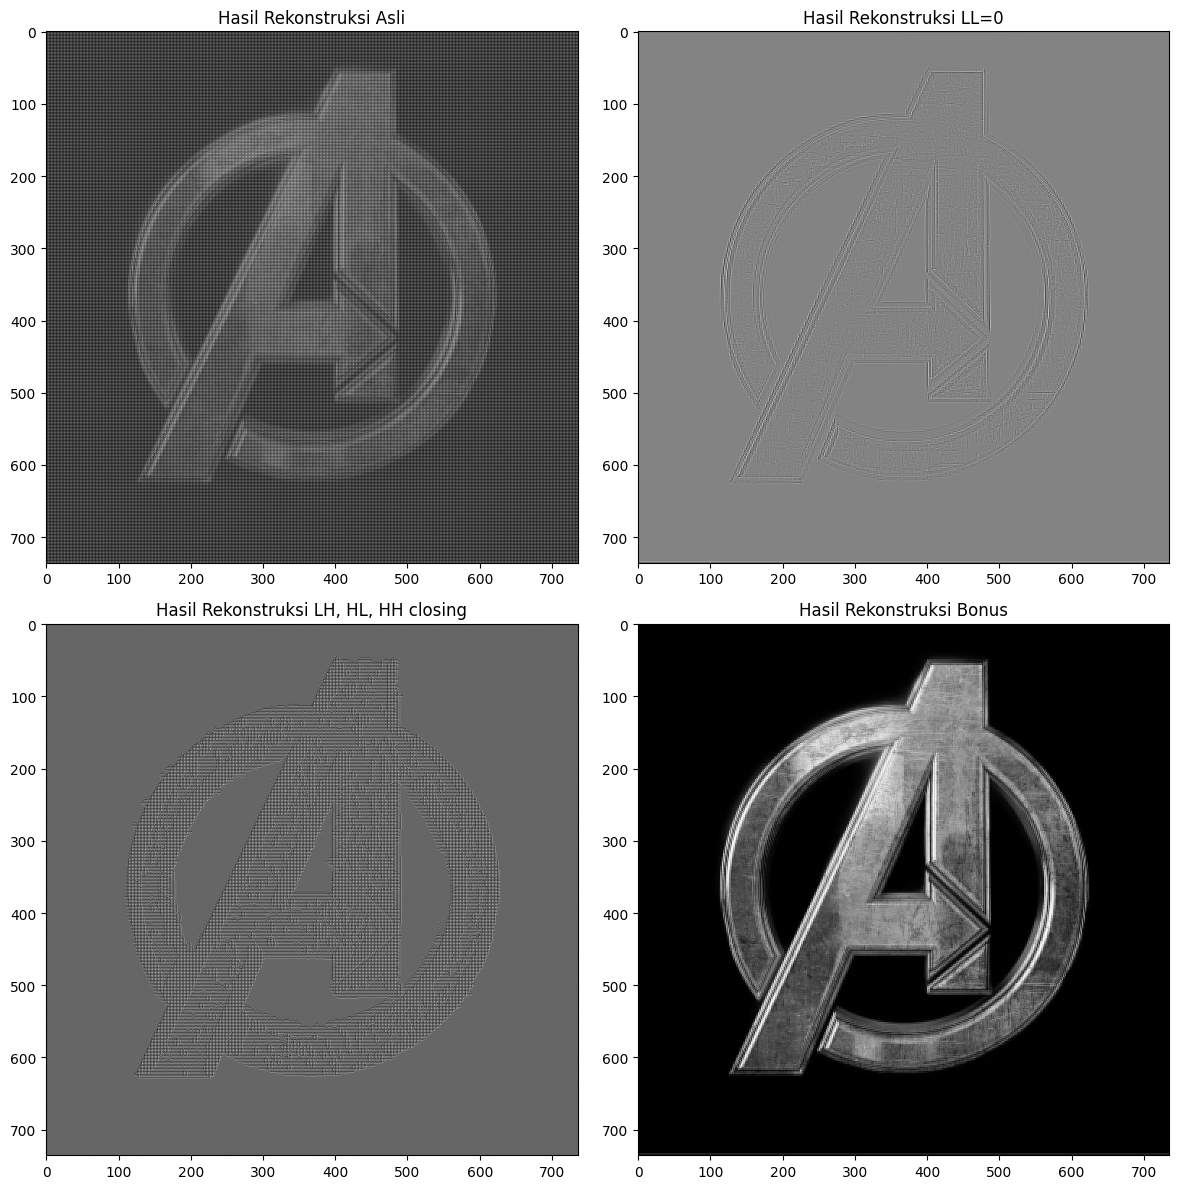

In [96]:
img_asli_a = rekonstruksi2(LL, LH, HL, HH)
LL_nol = np.zeros_like(LL)
img_rekonstruksi_b = rekonstruksi2(LL_nol, LH, HL, HH) 
img_rekonstruksi_b_display = normalisasi(img_rekonstruksi_b)

img_threshold_hl = threshold_manual(normalisasi(HL), 150)
img_threshold_lh = threshold_manual(normalisasi(LH), 150)
img_threshold_hh = threshold_manual(normalisasi(HH), 150)

closing_hl = metode_satu(img_threshold_hl, kernel5)
closing_lh = metode_satu(img_threshold_lh, kernel5)
closing_hh = metode_satu(img_threshold_hh, kernel5)

img_rekonstruksi_c = rekonstruksi2(LL_nol, closing_lh, closing_hl, closing_hh)
img_rekonstruksi_c_display = normalisasi(img_rekonstruksi_c)

img_rekonstruksi_bonus = normalisasi(img_asli_a)

plt.figure(figsize=(12, 12))

plt.subplot(2, 2, 1)
plt.imshow(rekonstruksi_img, cmap='gray')
plt.title("Hasil Rekonstruksi Asli")

plt.subplot(2, 2, 2)
plt.imshow(img_rekonstruksi_b_display, cmap='gray')
plt.title("Hasil Rekonstruksi LL=0")

plt.subplot(2, 2, 3)
plt.imshow(img_rekonstruksi_c_display, cmap='gray')
plt.title("Hasil Rekonstruksi LH, HL, HH closing")

plt.subplot(2, 2, 4)
plt.imshow(img_rekonstruksi_bonus, cmap='gray')
plt.title("Hasil Rekonstruksi Bonus")

plt.tight_layout()
plt.show()